In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

pd.set_option('display.max_columns', 200)

In [44]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Personal/asteroid_project/data/processed/asteroids.csv')

In [45]:
df.shape

(1477090, 38)

In [46]:
df.head()

,H,G,Num_obs,rms,U,Arc_years,Perturbers,Perturbers_2,Number,Name,Principal_desig,Other_desigs,Epoch,M,Peri,Node,i,e,n,a,Ref,Num_opps,Computer,Hex_flags,Last_obs,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,Orbit_type,NEO_flag,One_km_NEO_flag,PHA_flag,One_opposition_object_flag,Arc_length,hazerdous
0,18.31,0.15,101.0,0.90,0,2003-2025,M-v,3Ek,(440131),NaN,2003 SR329,NaN,2461000.5,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,MPO891325,7,MPCLINUX,0000,2025-01-02,2.460586e+06,4.168255,2.018711,3.161326,1.231999,1.315631,MBA,NaN,NaN,NaN,NaN,NaN,0
1,17.14,0.15,250.0,0.89,0,2005-2024,M-v,3Ek,(596642),NaN,2005 YC185,"['2010 CY86', '2012 UW121', '2014 FL44']",2461000.5,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,MPO892149,13,MPCLINUX,0000,2024-12-20,2.461450e+06,3.859512,2.152733,2.768246,1.210998,1.349710,MBA,NaN,NaN,NaN,NaN,NaN,0
2,17.12,0.15,213.0,0.99,0,2008-2025,M-v,3Ek,(484515),NaN,2008 EL51,NaN,2461000.5,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,MPO905048,9,MPCLINUX,0000,2025-01-26,2.460966e+06,4.435521,2.023249,3.375913,1.265069,1.291077,MBA,NaN,NaN,NaN,NaN,NaN,0
3,18.15,0.15,206.0,0.95,0,2002-2025,M-v,3Ek,(660520),NaN,2002 AC173,NaN,2461000.5,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,MPO954653,12,MPCORBFIT,0000,2025-08-16,2.461486e+06,3.599953,2.024565,2.673236,1.152058,1.384622,MBA,NaN,NaN,NaN,NaN,NaN,0
4,15.36,0.15,1119.0,0.81,0,2001-2025,M-v,3Ek,(188731),NaN,2005 US54,NaN,2461000.5,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,MPO927334,18,MPCLINUX,0000,2025-06-14,2.461276e+06,4.267199,2.192614,3.069076,1.278924,1.306072,MBA,NaN,NaN,NaN,NaN,NaN,0


In [47]:
df.columns

Index(['H', 'G', 'Num_obs', 'rms', 'U', 'Arc_years', 'Perturbers',
       'Perturbers_2', 'Number', 'Name', 'Principal_desig', 'Other_desigs',
       'Epoch', 'M', 'Peri', 'Node', 'i', 'e', 'n', 'a', 'Ref', 'Num_opps',
       'Computer', 'Hex_flags', 'Last_obs', 'Tp', 'Orbital_period',
       'Perihelion_dist', 'Aphelion_dist', 'Semilatus_rectum',
       'Synodic_period', 'Orbit_type', 'NEO_flag', 'One_km_NEO_flag',
       'PHA_flag', 'One_opposition_object_flag', 'Arc_length', 'hazerdous'],
      dtype='object')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1477090 entries, 0 to 1477089
Data columns (total 38 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   H                           1476907 non-null  float64
 1   G                           1476907 non-null  float64
 2   Num_obs                     1477088 non-null  float64
 3   rms                         1477064 non-null  float64
 4   U                           1466709 non-null  object 
 5   Arc_years                   1302885 non-null  object 
 6   Perturbers                  1465477 non-null  object 
 7   Perturbers_2                1465477 non-null  object 
 8   Number                      875150 non-null   object 
 9   Name                        25716 non-null    object 
 10  Principal_desig             1477090 non-null  object 
 11  Other_desigs                388414 non-null   object 
 12  Epoch                       1477090 non-null  float64
 1

In [49]:
df.select_dtypes(include='object')

,U,Arc_years,Perturbers,Perturbers_2,Number,Name,Principal_desig,Other_desigs,Ref,Computer,Hex_flags,Last_obs,Orbit_type
0,0,2003-2025,M-v,3Ek,(440131),NaN,2003 SR329,NaN,MPO891325,MPCLINUX,0000,2025-01-02,MBA
1,0,2005-2024,M-v,3Ek,(596642),NaN,2005 YC185,"['2010 CY86', '2012 UW121', '2014 FL44']",MPO892149,MPCLINUX,0000,2024-12-20,MBA
2,0,2008-2025,M-v,3Ek,(484515),NaN,2008 EL51,NaN,MPO905048,MPCLINUX,0000,2025-01-26,MBA
3,0,2002-2025,M-v,3Ek,(660520),NaN,2002 AC173,NaN,MPO954653,MPCORBFIT,0000,2025-08-16,MBA
4,0,2001-2025,M-v,3Ek,(188731),NaN,2005 US54,NaN,MPO927334,MPCLINUX,0000,2025-06-14,MBA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477085,0,1977-2025,M-v,3Ek,(259474),NaN,2003 SX169,NaN,MPO916193,MPCLINUX,0000,2025-05-15,MBA
1477086,1,2007-2025,M-v,3Ek,NaN,NaN,2023 VP11,NaN,MPO907375,MPCLINUX,0008,2025-01-22,Hilda
1477087,0,1998-2025,M-v,3Ek,(132045),NaN,2002 CY132,NaN,MPO952068,MPCORBFIT,0000,2025-09-15,MBA
1477088,0,2005-2024,M-v,3Ek,(671984),NaN,2014 QU324,['2016 AP15'],MPO892538,MPCLINUX,0000,2024-12-23,MBA


In [50]:
for col in df.select_dtypes(include='object'):
  if col not in ['Arc_years', 'Number', 'Name', 'Principal_desig', 'Other_desigs', 'Ref', 'Computer', 'Last_obs']:
    print(f'unique values for {col}: {df[col].unique()}')

unique values for U: ['0' '6' '1' '8' '5' '2' '7' '9' '3' nan '4' 'E' 'D']
unique values for Perturbers: ['M-v' nan 'M-h' 'M-N' 'M-c' 'M-p']
unique values for Perturbers_2: ['3Ek' '3El' '38h' nan '3Eh' '08' '30k' '28k' '08h' '18k']
unique values for Hex_flags: ['0000' '2000' '0009' '0006' '2007' '000A' '0005' '2802' '2804' '0007'
 '0803' '200A' '2005' '2803' '0008' '8803' '2009' '8804' '2006' '0804'
 '0400' '1804' '1803' '0406' '9803' 'A804' '0802' '8802' '2008' 'A803'
 '3804' '0405' '1802' '040A' 'A802' '0408' '1801' '2801' '3803' '8801'
 '0801' '0C04' '9804' '0407' '0C03' 'B803' '9802' '8C04' '4007' '4000'
 '0C02' '280A' '080A' '0409' '8C02']
unique values for Orbit_type: ['MBA' 'Jupiter Trojan' 'Hungaria' 'Phocaea' 'Distant Object'
 'Object with perihelion distance < 1.665 AU' 'Aten' 'Amor' 'Apollo'
 'Hilda' 'Atira']


In [51]:
df.select_dtypes(include=['int64', 'float64'])

,H,G,Num_obs,rms,Epoch,M,Peri,Node,i,e,n,a,Num_opps,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,NEO_flag,One_km_NEO_flag,PHA_flag,One_opposition_object_flag,Arc_length,hazerdous
0,18.31,0.15,101.0,0.90,2461000.5,98.01667,21.29490,20.45607,2.17419,0.220580,0.236456,2.590018,7,2.460586e+06,4.168255,2.018711,3.161326,1.231999,1.315631,NaN,NaN,NaN,NaN,NaN,0
1,17.14,0.15,250.0,0.89,2461000.5,245.12922,329.93421,318.53094,4.99459,0.125079,0.255371,2.460490,13,2.461450e+06,3.859512,2.152733,2.768246,1.210998,1.349710,NaN,NaN,NaN,NaN,NaN,0
2,17.12,0.15,213.0,0.99,2461000.5,7.73489,333.54655,190.29557,15.46781,0.250532,0.222208,2.699581,9,2.460966e+06,4.435521,2.023249,3.375913,1.265069,1.291077,NaN,NaN,NaN,NaN,NaN,0
3,18.15,0.15,206.0,0.95,2461000.5,227.02952,5.59939,113.34616,2.06068,0.138080,0.273783,2.348900,12,2.461486e+06,3.599953,2.024565,2.673236,1.152058,1.384622,NaN,NaN,NaN,NaN,NaN,0
4,15.36,0.15,1119.0,0.81,2461000.5,296.32977,319.59282,28.96358,14.85383,0.166574,0.230973,2.630845,18,2.461276e+06,4.267199,2.192614,3.069076,1.278924,1.306072,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1477085,16.80,0.15,670.0,0.87,2461000.5,340.63291,78.86674,221.01017,6.01269,0.123230,0.302369,2.198424,17,2.461065e+06,3.259622,1.927511,2.469337,1.082520,1.442552,NaN,NaN,NaN,NaN,NaN,0
1477086,16.98,0.15,33.0,0.43,2461000.5,92.19696,311.33257,106.21730,4.29026,0.177540,0.124562,3.970799,6,2.460260e+06,7.912557,3.265822,4.675776,1.922818,1.144664,NaN,NaN,NaN,NaN,NaN,0
1477087,16.79,0.15,598.0,0.80,2461000.5,107.25030,27.72002,194.96491,0.79093,0.135780,0.267411,2.386068,18,2.460599e+06,3.685737,2.062087,2.710050,1.171039,1.372337,NaN,NaN,NaN,NaN,NaN,0
1477088,17.54,0.15,136.0,0.88,2461000.5,164.74466,238.79382,81.82374,3.15423,0.069401,0.206451,2.835250,10,2.460203e+06,4.774052,2.638480,3.032020,1.410797,1.264967,NaN,NaN,NaN,NaN,NaN,0


In [52]:
df.describe().round(3)

,H,G,Num_obs,rms,Epoch,M,Peri,Node,i,e,n,a,Num_opps,Tp,Orbital_period,Perihelion_dist,Aphelion_dist,Semilatus_rectum,Synodic_period,NEO_flag,One_km_NEO_flag,PHA_flag,One_opposition_object_flag,Arc_length,hazerdous
count,1476907.000,1476907.000,1477088.000,1477064.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,1477090.000,39876.0,1407.0,2510.0,161861.0,174205.000,1477090.000
mean,17.575,0.150,328.718,0.664,2460963.331,177.873,181.822,169.550,9.346,0.159,0.235,2.913,9.123,2460940.396,6.863,2.408,3.417,1.384,1.394,1.0,1.0,1.0,1.0,26.358,0.002
std,1.941,0.001,686.929,0.261,448.332,104.644,103.784,102.879,6.659,0.095,0.084,6.869,6.354,1513.796,298.293,2.186,12.866,1.311,5.588,0.0,0.0,0.0,0.0,26.533,0.041
min,-1.250,0.000,2.000,0.000,2425067.500,0.000,0.000,0.000,0.003,0.000,0.000,0.462,1.000,2340708.113,0.314,0.070,0.654,0.069,0.457,1.0,1.0,1.0,1.0,0.000,0.000
25%,16.660,0.150,42.000,0.420,2461000.500,86.989,91.885,81.566,4.410,0.093,0.187,2.398,4.000,2460592.772,3.714,1.971,2.803,1.160,1.234,1.0,1.0,1.0,1.0,6.000,0.000
50%,17.570,0.150,103.000,0.750,2461000.500,176.050,183.626,161.277,7.938,0.148,0.226,2.666,8.000,2460977.605,4.353,2.241,3.084,1.292,1.298,1.0,1.0,1.0,1.0,21.000,0.000
75%,18.450,0.150,296.000,0.880,2461000.500,268.617,271.672,254.772,12.732,0.205,0.265,3.027,13.000,2461374.771,5.266,2.591,3.397,1.472,1.368,1.0,1.0,1.0,1.0,36.000,0.000
max,99.990,0.150,18486.000,9.990,2461000.500,360.000,360.000,359.999,175.976,0.997,3.141,4225.555,126.000,2667683.375,274679.146,80.636,8427.388,70.936,5533.337,1.0,1.0,1.0,1.0,262.000,1.000


<Figure size 1200x600 with 0 Axes>

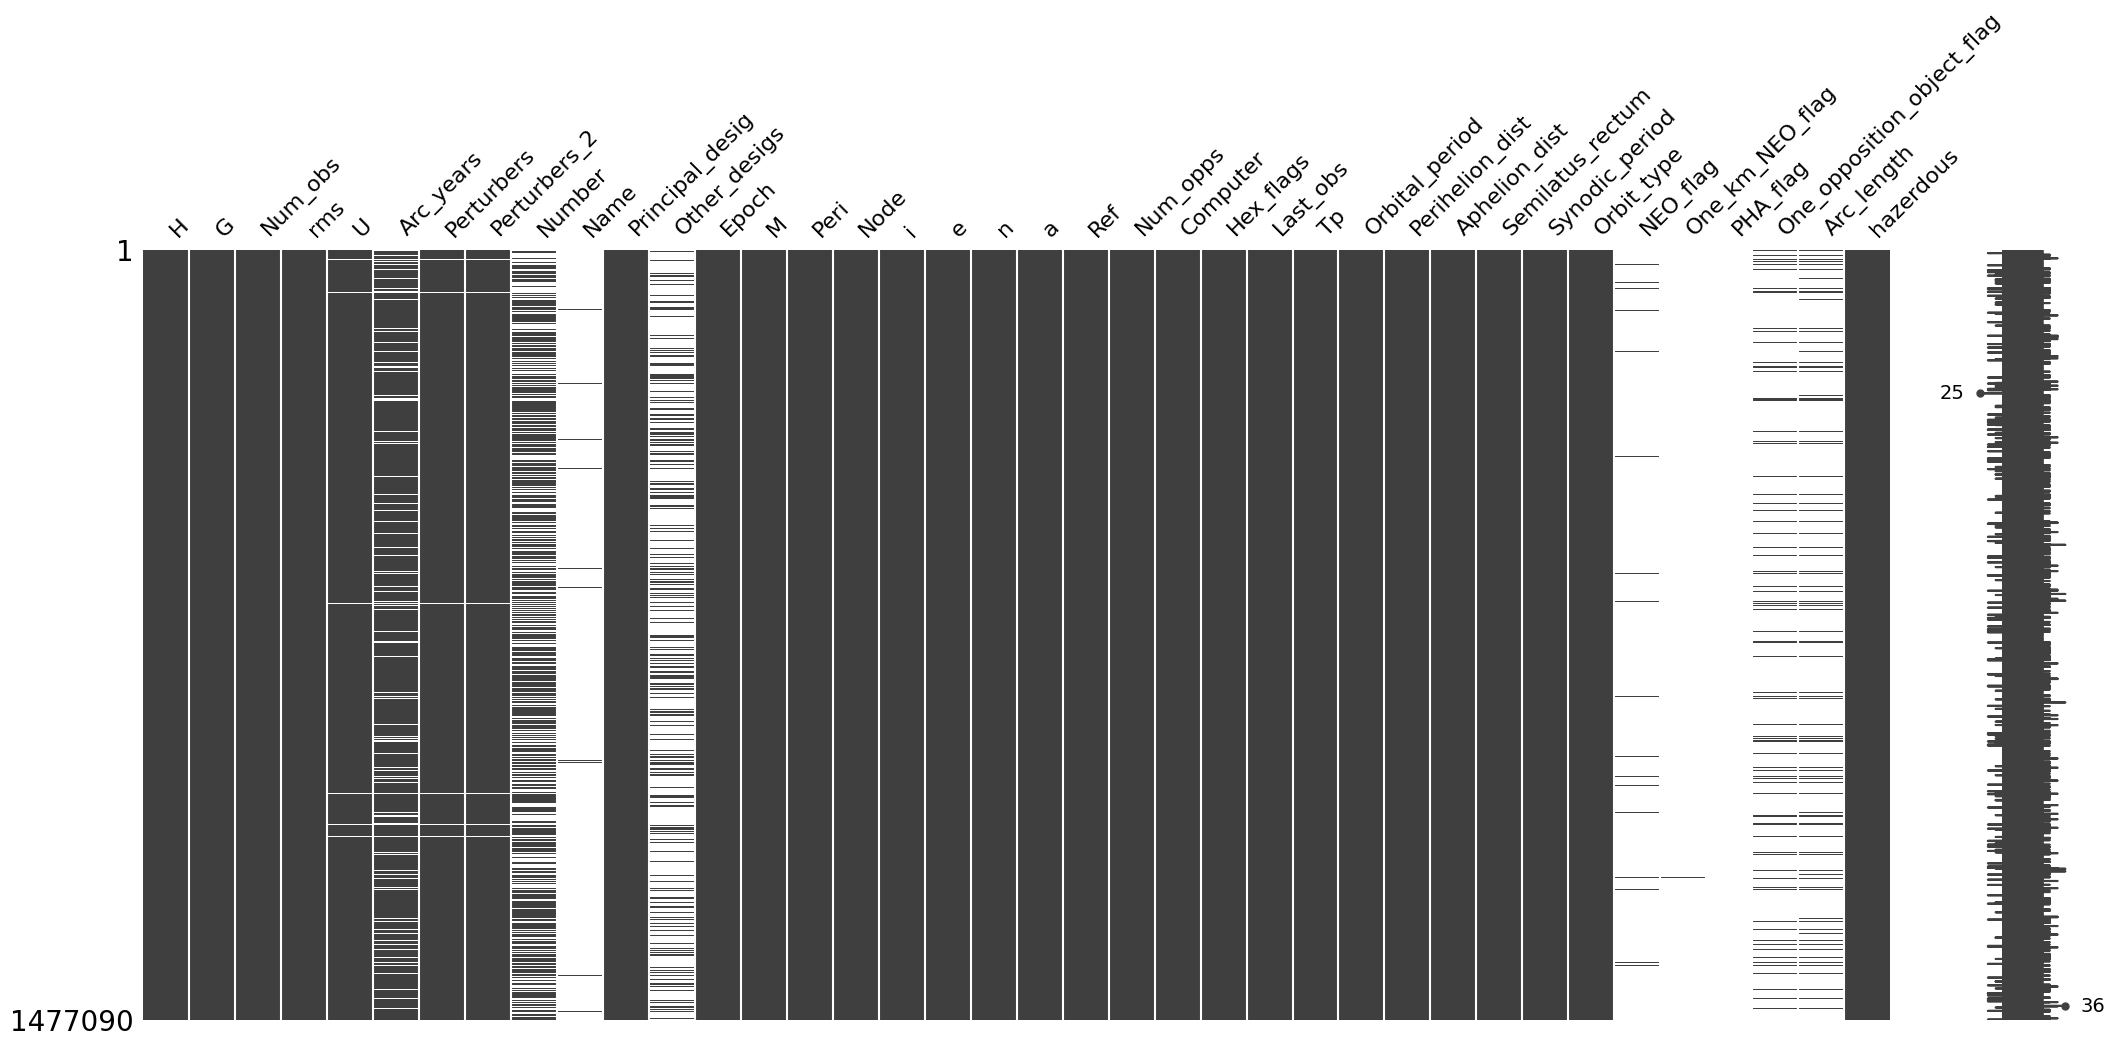

In [53]:
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.show()

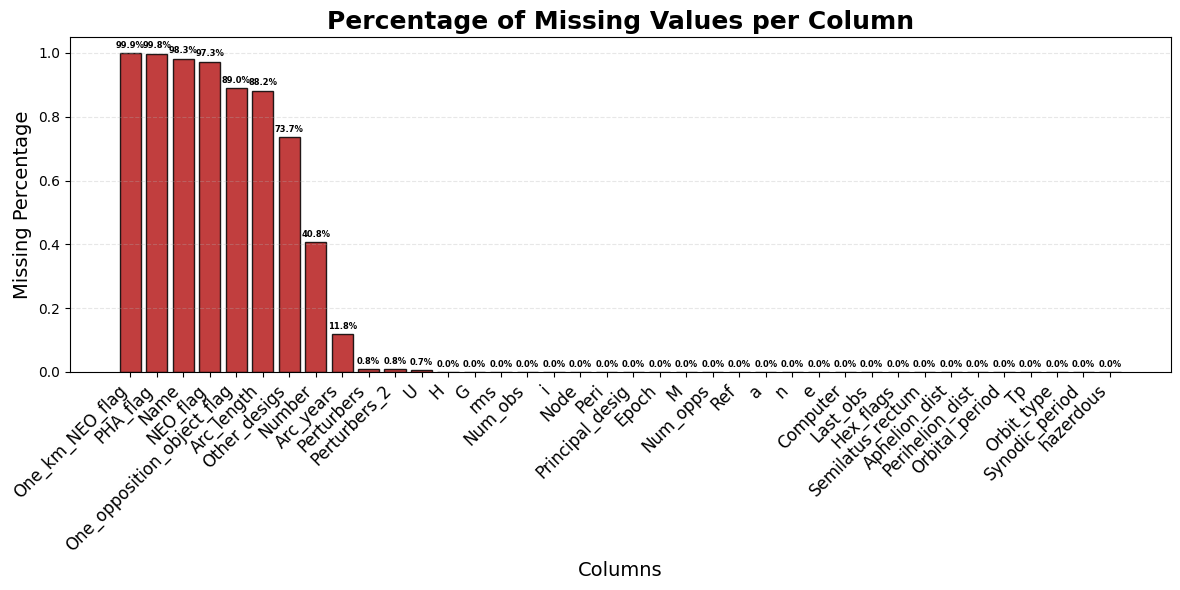

In [54]:
missing_percent = df.isna().sum().sort_values(ascending=False) / df.shape[0]


plt.figure(figsize=(12,6))
bars = plt.bar(
    missing_percent.index,
    missing_percent.values,
    color="#B71C1C",
    edgecolor="black",
    alpha=0.85
)

plt.xticks(rotation=45, ha='right', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold'
    )

plt.title("Percentage of Missing Values per Column", fontsize=18, fontweight="bold")
plt.xlabel("Columns", fontsize=14)
plt.ylabel("Missing Percentage", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.duplicated(subset='Principal_desig').sum()

np.int64(0)

## Classification & Flags

| Column | Meaning |
|--------|---------|
| **Orbit_type** | Taxonomy such as: MBA (Main-belt asteroid), APO (Apollo), AMO (Amor), ATE (Aten), etc. |
| **NEO_flag** | Near-Earth Object (1 = yes). |
| **One_km_NEO_flag** | NEO estimated to be >1 km in diameter. |
| **PHA_flag** | Potentially Hazardous Asteroid (1 = yes). |

---


## Asteroid Identification

| Column | Meaning |
|--------|---------|
| **Number** | Asteroid’s assigned number (e.g., 433 for Eros). Only well-known asteroids have a number. |
| **Name** | Asteroid name (very few have this). |
| **Principal_desig** | Primary designation (e.g., 2021 AB). |
| **Other_desigs** | Additional designations or aliases. |

---


## Metadata

| Column | Meaning |
|--------|---------|
| **Ref** | Orbit computation reference code. |
| **Num_opps** | Number of oppositions observed. |
| **Computer** | Software/system that computed the orbit. |
| **Hex_flags** | Internal hexadecimal flags for orbit processing. |
| **Last_obs** | Date of last observation (YYYY-MM-DD). |

## Perturbers

| Column | Meaning |
|--------|---------|
| **Perturbers** | Planetary perturbers included in orbit solution (e.g., “M-v” means Moon & Venus). |
| **Perturbers_2** | Secondary perturber list (MPC format sometimes splits this). |

---


In [ ]:
df.drop(['NEO_flag','Perturbers', 'Perturbers_2', 'Number', 'Name', 'Principal_desig',
 'Other_desigs', 'Ref', 'Computer', 'Hex_flags', 'Last_obs',
 'One_km_NEO_flag', 'PHA_flag', 'One_opposition_object_flag', 'Arc_length'],
        axis=1,
        inplace=True
        )

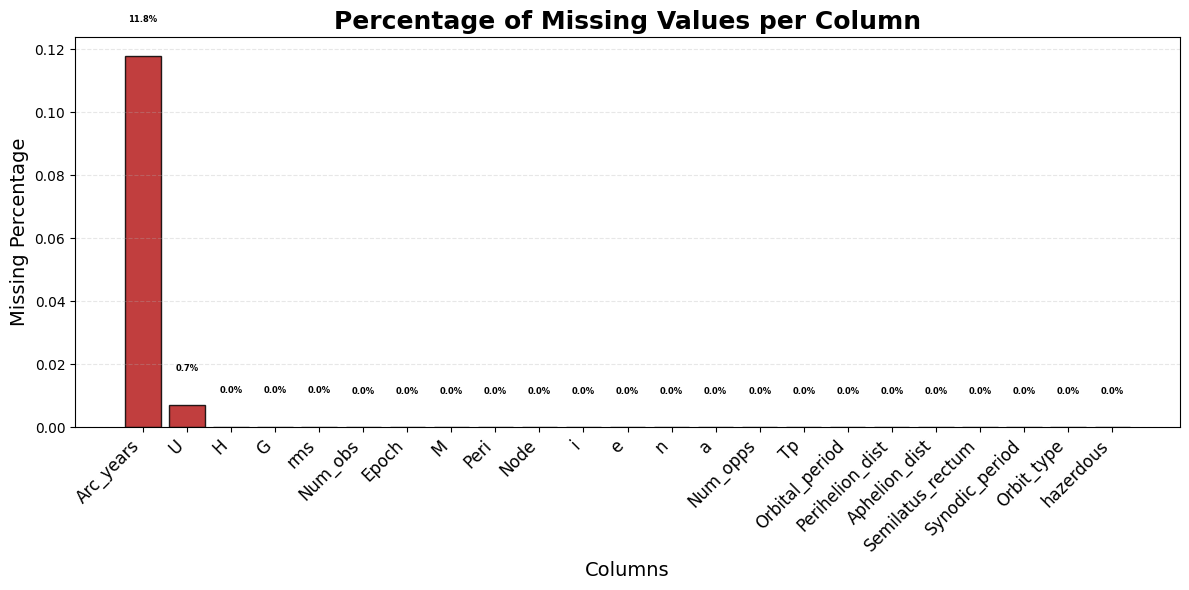

In [60]:
missing_percent = df.isna().sum().sort_values(ascending=False) / df.shape[0]


plt.figure(figsize=(12,6))
bars = plt.bar(
    missing_percent.index,
    missing_percent.values,
    color="#B71C1C",
    edgecolor="black",
    alpha=0.85
)

plt.xticks(rotation=45, ha='right', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.1%}',
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold'
    )

plt.title("Percentage of Missing Values per Column", fontsize=18, fontweight="bold")
plt.xlabel("Columns", fontsize=14)
plt.ylabel("Missing Percentage", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [63]:
df['Arc_years'].head(5)

,Arc_years
0,2003-2025
1,2005-2024
2,2008-2025
3,2002-2025
4,2001-2025


In [68]:
def transform_arc_years(val):
    if pd.isna(val):
        return np.nan

    val = str(val).strip()
    if val == "" or val.lower() == "none":
        return np.nan

    parts = val.split('-')


    try:
        start = float(parts[0]) if parts[0] != "" else np.nan
        end = float(parts[1]) if len(parts) > 1 and parts[1] != "" else np.nan
    except:
        return np.nan


    if pd.isna(start) and pd.isna(end):
        return np.nan


    if pd.isna(start) or pd.isna(end):
        return np.nan

    return end - start

df['Arc_years'] = df['Arc_years'].apply(transform_arc_years)


<Axes: >

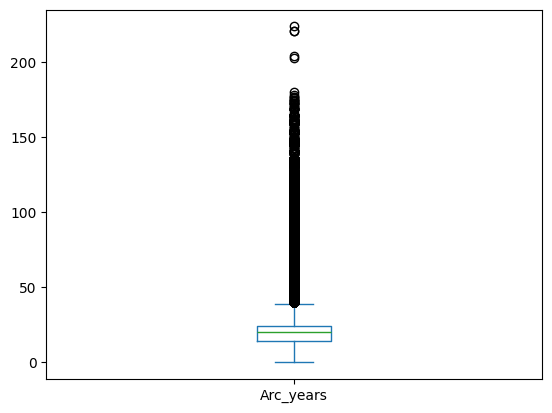

In [69]:
df['Arc_years'].plot(kind='box')

In [75]:
print(df['U'].sort_values().unique())

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. nan]


In [71]:
def transform_U(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val == "" or val.lower() == "none":
        return np.nan
    elif val.upper() == 'E' or val.upper() == 'D':
      return 9
    else:
      return int(val)

df['U'] = df['U'].apply(transform_U)

<Axes: >

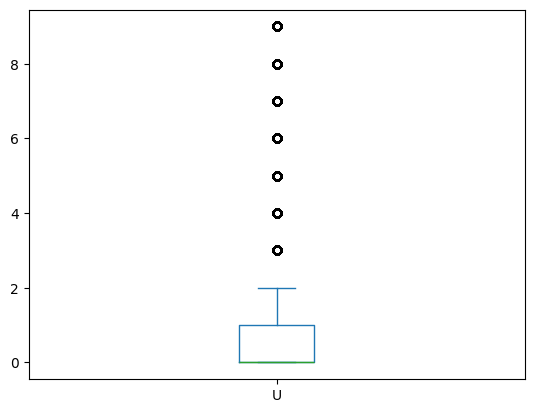

In [72]:
df['U'].plot(kind='box')

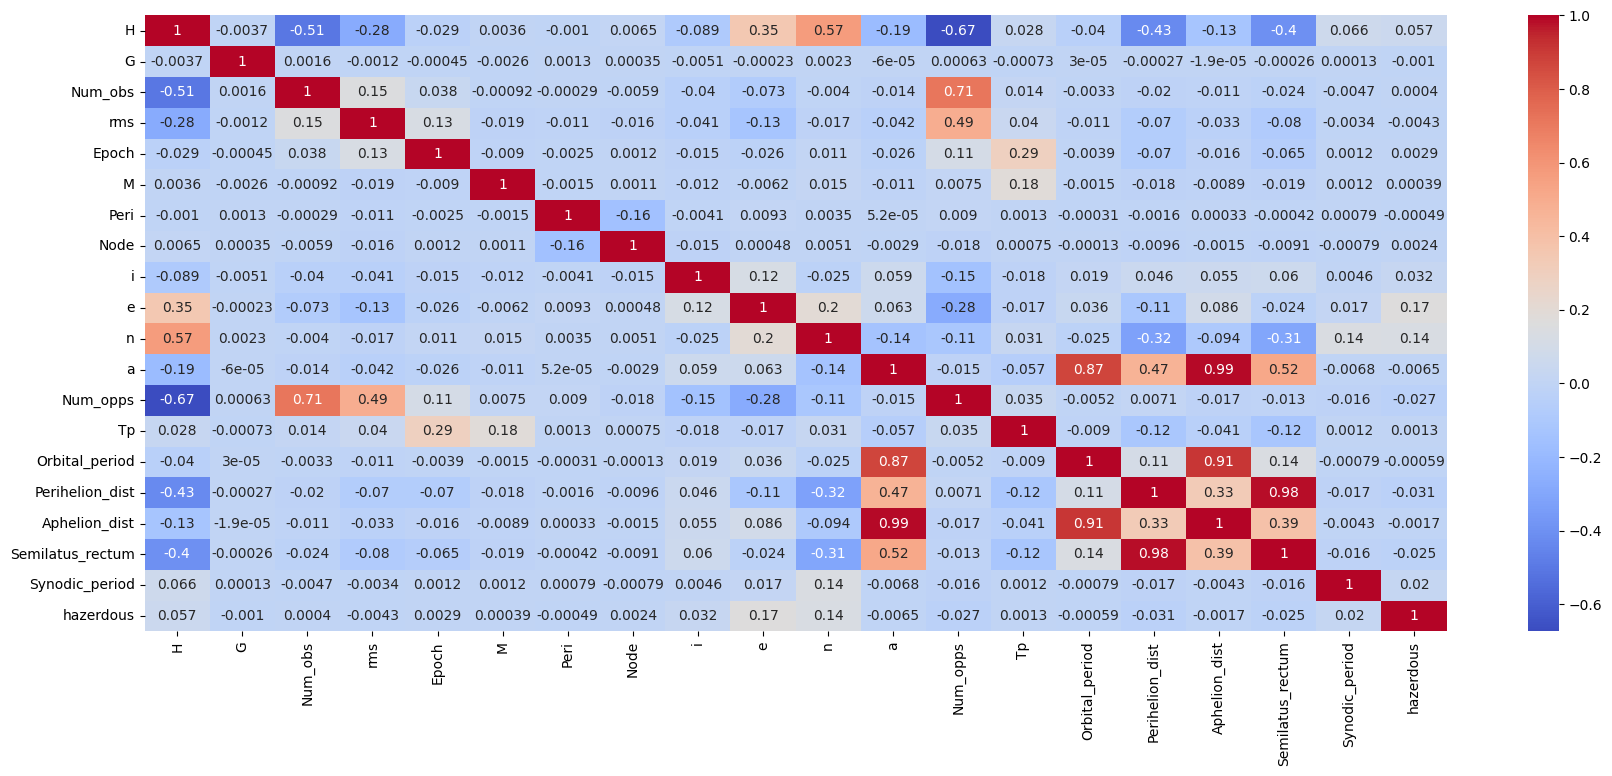

In [59]:
plt.figure(figsize=(21, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [58]:
df.corr(numeric_only=True)['hazerdous'].sort_values(ascending=False)

,hazerdous
hazerdous,1.000000
e,0.165621
n,0.135635
H,0.056638
i,0.031654
Synodic_period,0.019569
Epoch,0.002919
Node,0.002450
Tp,0.001257
Num_obs,0.000398
